In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-21d8wkzt
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-21d8wkzt
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c8830f9140a5828bae2a67427017099c9b0f9d6159e52d52bab5ca655e547328
  Stored in directory: /tmp/pip-ephem-wheel-cache-fir1089m/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing install

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


# Import thư viện

In [ ]:
import torch
import clip
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


# LOAD CLIP

In [ ]:
model, preprocess = clip.load("ViT-B/32", device=device)
model = model.float()

# DATASET

In [ ]:
class BirdDataset(Dataset):
    def __init__(self, root, transform):
        self.samples = []
        self.classes = sorted(os.listdir(root))

        for i, cls in enumerate(self.classes):
            cls_path = os.path.join(root, cls)
            for f in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, f), i))


        self.transform = transform

    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), label

# LOAD DATA

In [ ]:
data_root = "/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original"

train_set = BirdDataset(f"{data_root}/train", preprocess)
val_set   = BirdDataset(f"{data_root}/val", preprocess)
test_set  = BirdDataset(f"{data_root}/test", preprocess)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set, batch_size=16, shuffle= True, num_workers=2)

num_classes = len(train_set.classes)

print(train_set.classes)


classes = train_set.classes

print("Classes:", num_classes)

['ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALPINE CHOUGH', 'AMERICAN AVOCET', 'AMERICAN BITTERN', 'AMERICAN DIPPER', 'AMERICAN PIPIT', 'AMERICAN WIGEON', 'ASHY STORM PETREL', 'ASIAN GREEN BEE EATER', 'ASIAN OPENBILL STORK', 'AUCKLAND SHAQ', 'AUSTRALASIAN FIGBIRD', 'AZARAS SPINETAIL', 'BANDED BROADBILL', 'BAR-TAILED GODWIT', 'BLACK BREASTED PUFFBIRD', 'BLACK HEADED CAIQUE', 'BLACK NECKED STILT', 'BLACK VENTED SHEARWATER', 'BLACK-THROATED SPARROW', 'BLUE DACNIS', 'BLUE GRAY GNATCATCHER', 'BLUE GROSBEAK', 'BLUE GROUSE', 'BLUE HERON', 'BLUE MALKOHA', 'BLUE THROATED PIPING GUAN', 'BREWERS BLACKBIRD', 'BROWN CREPPER', 'BROWN HEADED COWBIRD', 'BUFFLEHEAD', 'CABOTS TRAGOPAN', 'CAMPO FLICKER', 'CANVASBACK', 'CASPIAN TERN', 'CEDAR WAXWING', 'CHESTNUT WINGED CUCKOO', 'CHUKAR PARTRIDGE', 'CLARKS GREBE', 'COLLARED ARACARI', 'COLLARED CRESCENTCHEST', 'COMMON GRACKLE', 'COPPERSMITH BARBET', 'CRESTED SERPENT EAGLE', 'CRESTED WOOD PARTRIDGE', 'CRIMS

# MODEL (FINE-TUNE)

In [ ]:
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip = clip_model

        # Freeze toàn bộ CLIP
        for p in self.clip.parameters():
            p.requires_grad = False

        # Fine-tune 2 block cuối
        for p in self.clip.visual.transformer.resblocks[-2:].parameters():
            p.requires_grad = True

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # Init weight
        for m in self.fc:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, x):
        features = self.clip.encode_image(x).float()

        # Normalize (ổn định số học)
        norm = torch.clamp(features.norm(dim=-1, keepdim=True), min=1e-6)
        features = features / norm

        # Scale (giữ ổn định logits)
        features = features * 10

        return self.fc(features)

# LOSS + OPTIMIZER

In [ ]:
model_cls = CLIPClassifier(model, num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": model_cls.clip.parameters(), "lr": 1e-6},
    {"params": model_cls.fc.parameters(), "lr":  1e-5},
])

# Total params

In [ ]:
total = 0
for name, param in model_cls.named_parameters():
    total += param.numel()

print("Total params:", total)

Total params: 151447191


# TRAIN + VALIDATION

In [ ]:
best_val_acc = 0
patience = 2
counter = 0

start_train_time = time.time()

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 10

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model_cls.train()
    total_loss = 0
    correct = 0
    total = 0
    nan_flag = False

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        if not torch.isfinite(images).all():
            print("❌ Bad input")
            continue   # 🔥 đổi break → continue

        optimizer.zero_grad()
        outputs = model_cls(images)

        if not torch.isfinite(outputs).all():
            print("❌ Output exploded")
            continue

        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            print("❌ NaN loss")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_cls.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        # ✅ FIX: tính accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # ===== METRICS =====
    avg_train_loss = total_loss / len(train_loader) if len(train_loader) > 0 else 0
    train_acc = correct / total if total > 0 else 0

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ===== VALIDATION =====
    model_cls.eval()
    val_loss = 0   # ✅ FIX
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_cls(images)
            loss = criterion(outputs, labels)   # ✅ FIX

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_acc = correct / total if total > 0 else 0

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # ===== SAVE BEST =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model_cls.state_dict(), "/kaggle/working/birds_dataset_original_model.pth")
        print("✅ Saved best model")
    else:
        counter += 1

    # ===== EARLY STOPPING =====
    if counter >= patience:
        print("⛔ Early stopping!")
        break

Epoch 1/10 | Train Loss: 4.7967 | Val Loss: 4.3827 | Train Acc: 0.0434 | Val Acc: 0.1511
✅ Saved best model
Epoch 2/10 | Train Loss: 3.9928 | Val Loss: 3.4973 | Train Acc: 0.2088 | Val Acc: 0.4461
✅ Saved best model
Epoch 3/10 | Train Loss: 3.1703 | Val Loss: 2.7236 | Train Acc: 0.4318 | Val Acc: 0.6693
✅ Saved best model
Epoch 4/10 | Train Loss: 2.4927 | Val Loss: 2.0746 | Train Acc: 0.5998 | Val Acc: 0.7811
✅ Saved best model
Epoch 5/10 | Train Loss: 1.9234 | Val Loss: 1.5594 | Train Acc: 0.7084 | Val Acc: 0.8402
✅ Saved best model
Epoch 6/10 | Train Loss: 1.4839 | Val Loss: 1.1831 | Train Acc: 0.7783 | Val Acc: 0.8795
✅ Saved best model
Epoch 7/10 | Train Loss: 1.1596 | Val Loss: 0.9179 | Train Acc: 0.8262 | Val Acc: 0.8936
✅ Saved best model
Epoch 8/10 | Train Loss: 0.9187 | Val Loss: 0.7298 | Train Acc: 0.8609 | Val Acc: 0.9075
✅ Saved best model
Epoch 9/10 | Train Loss: 0.7452 | Val Loss: 0.6012 | Train Acc: 0.8824 | Val Acc: 0.9150
✅ Saved best model
Epoch 10/10 | Train Loss: 0.

# Đánh giá

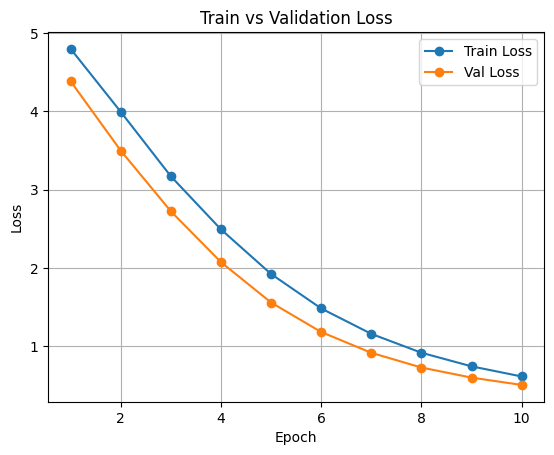

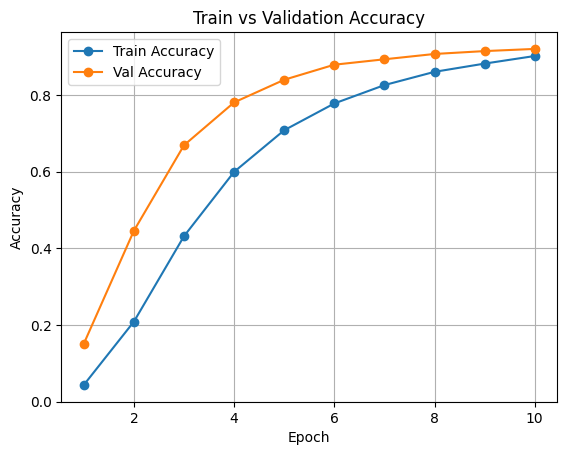

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# ===== LOSS =====
plt.figure()
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# ===== ACCURACY =====
plt.figure()
plt.plot(epochs, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker='o', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print("\n===== TEST RESULT =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
evaluate(model_cls, test_loader)


===== TEST RESULT =====
Accuracy : 0.9264
Precision: 0.9294
Recall   : 0.9264
F1-score : 0.9265

Confusion Matrix:
[[22  0  0 ...  0  0  0]
 [ 0 27  1 ...  0  0  0]
 [ 0  0 30 ...  0  0  0]
 ...
 [ 0  0  0 ... 28  0  0]
 [ 0  0  0 ...  0 31  0]
 [ 0  0  0 ...  0  0 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73        29
           1       0.96      0.93      0.95        29
           2       0.86      1.00      0.92        30
           3       0.90      0.90      0.90        29
           4       0.93      0.93      0.93        27
           5       1.00      0.90      0.95        29
           6       0.96      0.96      0.96        27
           7       0.90      0.93      0.92        30
           8       0.90      0.97      0.93        29
           9       1.00      0.90      0.95        30
          10       0.86      0.80      0.83        30
          11       1.00      0.97      0.98        33
 

In [ ]:
model_cls.load_state_dict(torch.load("birds_dataset_original_model.pth"))
model_cls = model_cls.to(device)
model_cls.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_cls(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("🔥 Test Accuracy:", correct / total)

🔥 Test Accuracy: 0.9263652641002685


# Time train

In [ ]:
end_train_time = time.time()
train_time = end_train_time - start_train_time

print(f"\n⏱️ Training time: {train_time:.2f} seconds")


⏱️ Training time: 1385.77 seconds


# INFERENCE TIME (CPU & GPU)

In [ ]:
def measure_inference_time(model, dataloader, device, num_batches=50):
    model.eval()
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        start = time.time()

        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(device)

            if device == "cuda":
                torch.cuda.synchronize()

            t0 = time.time()
            outputs = model(images)

            if device == "cuda":
                torch.cuda.synchronize()

            t1 = time.time()

            total_time += (t1 - t0)
            total_samples += images.size(0)

    avg_time = total_time / total_samples
    return avg_time

In [ ]:
# GPU
gpu_time = measure_inference_time(model_cls, test_loader, "cuda")
print(f"🚀 Inference GPU: {gpu_time*1000:.4f} ms/sample")

# CPU
model_cpu = model_cls.to("cpu")
cpu_time = measure_inference_time(model_cpu, test_loader, "cpu")
print(f"💻 Inference CPU: {cpu_time*1000:.4f} ms/sample")

🚀 Inference GPU: 3.1242 ms/sample
💻 Inference CPU: 48.1491 ms/sample


#  Model size

In [ ]:
def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2
    return size_mb

In [ ]:
model_size = get_model_size(model_cls)
print(f" Model size: {model_size:.2f} MB")

 Model size: 577.73 MB


# In ảnh dự đoán đúng và sai

In [ ]:
from torchvision import datasets, transforms

test_dir = "/kaggle/input/datasets/anhnguynduyhong/birds-dataset-original/test"

test_dataset = datasets.ImageFolder(root=test_dir, transform=preprocess)

In [ ]:
model_cls.eval()

correct_imgs, correct_info = [], []
wrong_imgs, wrong_info = [], []

# 🔥 SHUFFLE TOÀN BỘ INDEX
all_indices = list(range(len(test_dataset)))
random.shuffle(all_indices)

with torch.no_grad():
    for idx in all_indices:
        img, label = test_dataset[idx]

        input_img = img.unsqueeze(0).to(device)
        output = model_cls(input_img)
        pred = output.argmax(dim=1).item()

        # UNNORMALIZE
        img_vis = img.permute(1, 2, 0).numpy()
        img_vis = (img_vis * np.array([0.2686, 0.2613, 0.2758]) +
                   np.array([0.4815, 0.4578, 0.4082]))
        img_vis = np.clip(img_vis, 0, 1)

        # PHÂN LOẠI
        if pred == label:
            if len(correct_imgs) < 25:
                correct_imgs.append(img_vis)
                correct_info.append((pred, label))
        else:
            if len(wrong_imgs) < 25:
                wrong_imgs.append(img_vis)
                wrong_info.append((pred, label))

        # DỪNG SỚM
        if len(correct_imgs) >= 25 and len(wrong_imgs) >= 25:
            break

In [ ]:
def show_grid(images, info, title):
    if len(images) == 0:
        print(f"Không có ảnh: {title}")
        return

    plt.figure(figsize=(12, 12))

    for i in range(len(images)):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

        pred, label = info[i]

        plt.title(
            f"P: {classes[pred]}\nT: {classes[label]}",
            fontsize=8
        )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

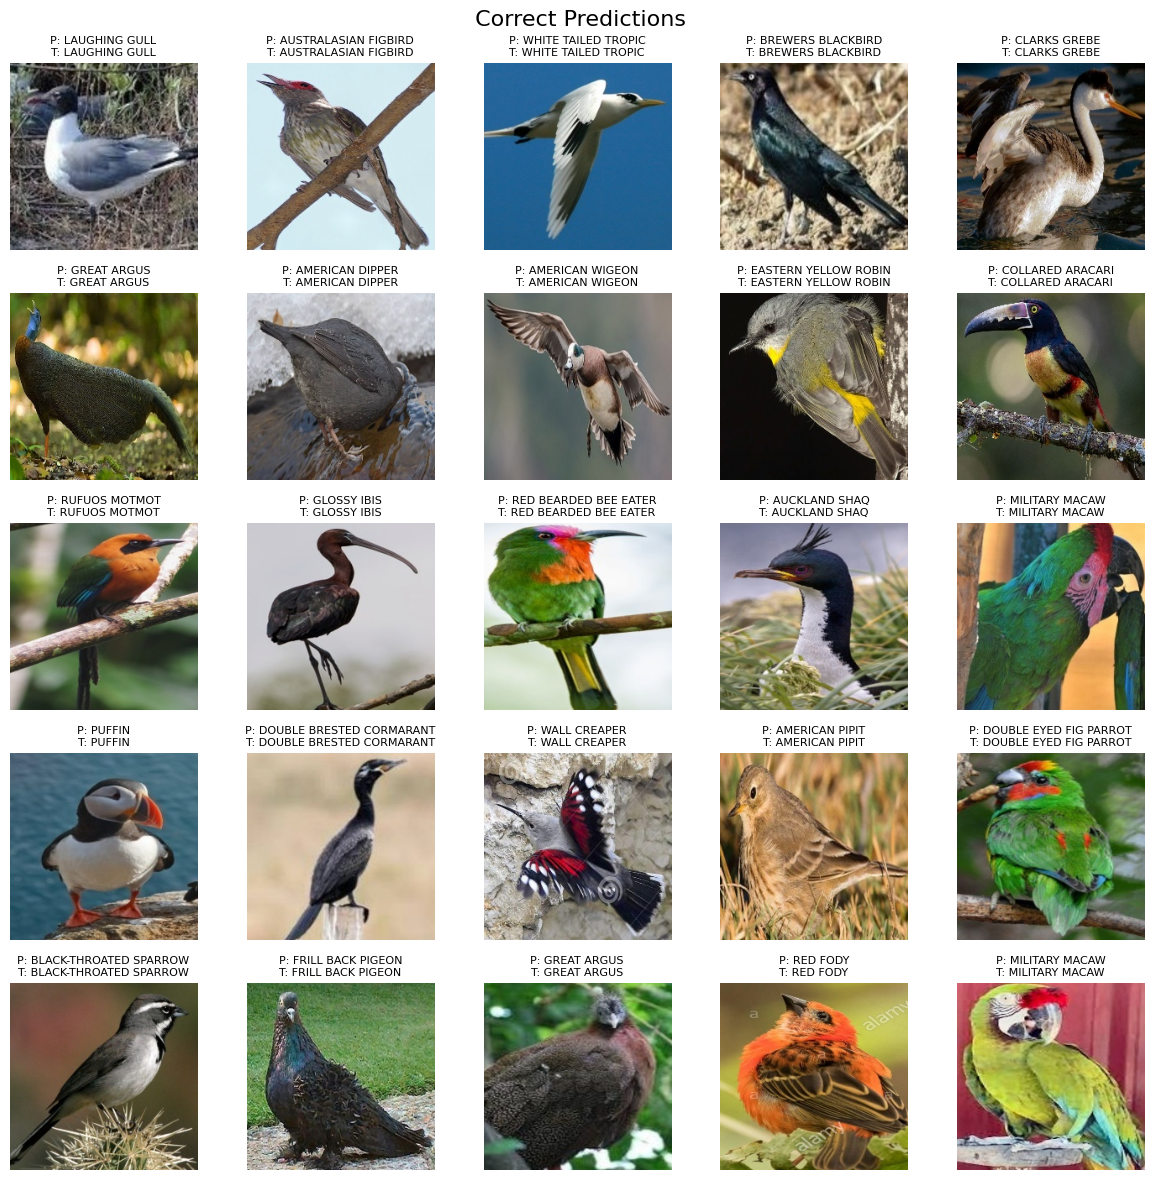

/tmp/ipykernel_55/3053118937.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


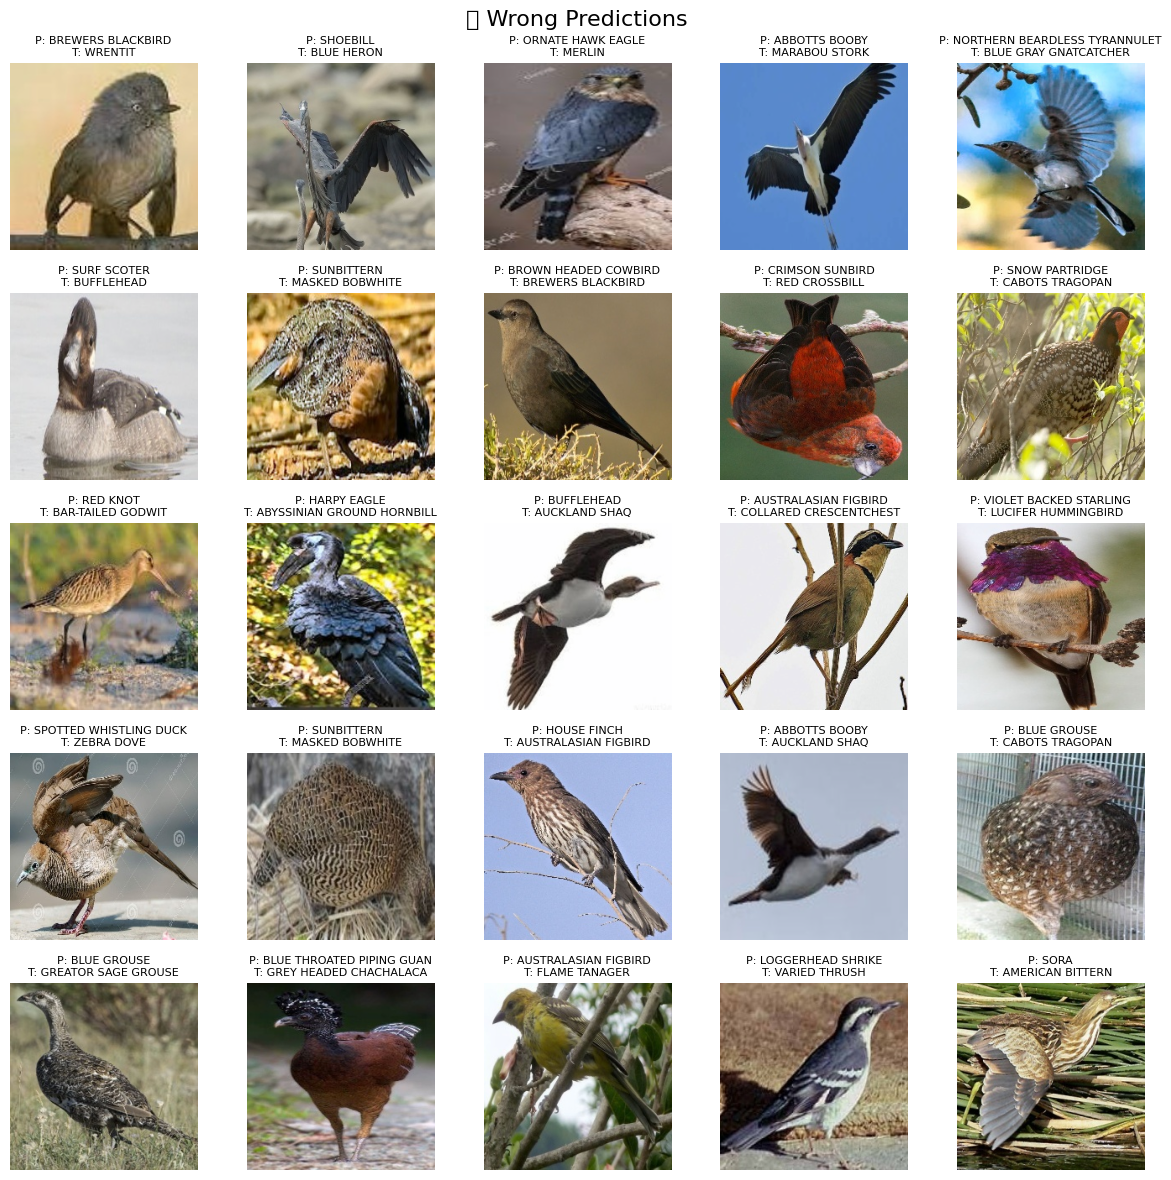

In [ ]:
show_grid(correct_imgs, correct_info, " Correct Predictions")
show_grid(wrong_imgs, wrong_info, " Wrong Predictions")